WEATHERCAST-ML-SYSTEM

weathercast-ml-system/
│
├── data/
│   ├── raw/
│   │   └── weather.csv
│   └── processed/
│
├── models/
│   └── model.pkl
│
├── notebooks/
│   └── eda.ipynb
│
├── src/
│   ├── __init__.py
│   ├── data_loader.py
│   ├── preprocess.py
│   ├── split.py
│   ├── train.py
│   ├── evaluate.py
│   ├── predict.py
│   └── utils.py
│
├── app/
│   ├── app.py
│   ├── templates/
│   │   └── index.html
│   └── static/
│
├── config/
│   └── config.yaml
│
├── requirements.txt
├── README.md
└── .gitignore


🏗 PHASE 1 — Model Foundation (15 Hours)
Step 1 — Clean Time Split (2 hrs)

Train: 2019–2022

Validation: 2023

Test: last portion (or simulated 2024)

No random split.

Step 2 — Proper Feature Engineering (4 hrs)

Add:

Lag features (1, 3, 7 days)

Rolling mean (7, 14 days)

Month, DayOfYear

Optional: sin/cos cyclical encoding

Step 3 — Learn RandomForest (5 hrs)

You must understand:

What is a decision tree?

What is bagging?

Why ensemble reduces variance?

Key hyperparameters:

n_estimators

max_depth

min_samples_split

Not just use it. Understand it.

Step 4 — Overfitting Diagnosis (4 hrs)

Learn to read:

Train vs Validation R²

Bias vs Variance

Feature importance

This is critical for interviews.

🏗 PHASE 2 — Engineering Discipline (10 Hours)
Build Modular Structure
src/
  data_loader.py
  features.py
  train.py
  evaluate.py
  predict.py


No messy notebook-only logic.

Save model properly

Use:

joblib

Store in:

models/model.pkl

🏗 PHASE 3 — Deployment Learning (10–15 Hours)

This is your fear area.

We break it slowly:

1️⃣ Build Flask API (4–5 hrs)

Load model

Create /predict endpoint

Accept JSON input

Return prediction

2️⃣ Connect Simple HTML Form (2–3 hrs)

User input → POST request → show result

3️⃣ Deploy on Render (4–5 hrs)

Steps:

Push to GitHub

Add requirements.txt

Add Procfile

Connect Render

Deploy

That’s it.

No GPU needed.

There are three phase of this project:
1. Model Foundation
2. Engineering Discipline
3. Deployment and Learning

There are four main parts:

1. Data
2. ML Logic
3. Model Storage
4. App Deployment(frontend + API)

### Import Libraries and Load Data

Explore and Understand the Data

Use "df.head()" to view the first few rows.
Use "df.info()" to check data types and non-null counts.
Use "df.describe()" to get summary statistics and spot potential outliers.
Use "df.isnull().sum()" to count missing values in each column.

Handle Missing Data

Drop rows or columns with excessive missing data using df.dropna().
Impute missing values with a calculated statistic (mean, median, or mode) using df.fillna().
Code Example: df['column_name'].fillna(df['column_name'].median(), inplace=True).

Remove Duplicate Data

Check for duplicates using df.duplicated().sum().
Remove duplicate rows using df.drop_duplicates().

Fix Data Types and Structural Errors

Convert columns to correct types (e.g., string to numeric, string to datetime) using df.astype() or pd.to_datetime().
Fix structural errors and inconsistencies in formatting (e.g., standardizing "USA" and "United States") using df.replace() or string methods.

ML model can not handle the String. If there is any string, then change into the integer with the help of skylearn.preprocessing importing through the label encoder.

Like:
from skylearn.preprocessing import LabelEncoder
le= LabelEncoder()


ORDER
1. EDA
2. Handle missing values
3. Drop duplicates
4. Feature engineering
5. Encode target
6. Encode categorical features
7. Handle outliers
8. Train-test split
9. Scaling (after split)

In [2]:
import pandas as pd
import numpy as np

In [3]:
file_path= r'M:\ML_Project\weathercast-ml-system\data\raw\weatherAUS.csv'
df= pd.read_csv(file_path)

In [4]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [5]:
df.info

<bound method DataFrame.info of               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
145455  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
145456  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
145457  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
145458  2017-06-24    Uluru      7.8     27.0       0.0          NaN   
145459  2017-06-25    Uluru     14.9      NaN       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  \
0            NaN           W

In [6]:
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

In [7]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [8]:
cat_col= [col for col in df.columns if df[col].dtype== 'object']
num_col= [col for col in df.columns if df[col].dtype!= 'object']
print("Category Column: ",cat_col)
print("Numerical Column: ",num_col)

Category Column:  ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Numerical Column:  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [9]:
print("Sum of missing value in each columns: ",df.isnull().sum())

Sum of missing value in each columns:  Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [10]:
for col in num_col:
    df[col] = df[col].fillna(df[col].median())

for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])


In [11]:
print("Sum of missing value in each columns: ",df.isnull().sum())

Sum of missing value in each columns:  Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [13]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
145455    False
145456    False
145457    False
145458    False
145459    False
Length: 145460, dtype: bool

In [14]:
df = df.drop_duplicates()

In [15]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [16]:
# Convert Date formate
df['Date']= pd.to_datetime(df['Date'])
df['Year']= df['Date'].dt.year
df['Month']= df['Date'].dt.month
df['Day']= df['Date'].dt.day

In [17]:
print("Missing:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing: 0
Duplicates: 0


In [18]:
cat_col= [col for col in df.columns if df[col].dtype== 'object']
num_col= [col for col in df.columns if df[col].dtype!= 'object']
print("Category Column: ",cat_col)
print("Numerical Column: ",num_col)

Category Column:  ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Numerical Column:  ['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']


In [19]:
# Encoding the target
df['RainToday']= df['RainToday'].map({'Yes': 1, 'No':0})
df['RainTomorrow']= df['RainTomorrow'].map({'Yes': 1, 'No': 0})

In [20]:
cat_col= [col for col in df.columns if df[col].dtype== 'object']
num_col= [col for col in df.columns if df[col].dtype!= 'object']
print("Category Column: ",cat_col)
print("Numerical Column: ",num_col)

Category Column:  ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Numerical Column:  ['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Year', 'Month', 'Day']


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   Evaporation    145460 non-null  float64       
 6   Sunshine       145460 non-null  float64       
 7   WindGustDir    145460 non-null  object        
 8   WindGustSpeed  145460 non-null  float64       
 9   WindDir9am     145460 non-null  object        
 10  WindDir3pm     145460 non-null  object        
 11  WindSpeed9am   145460 non-null  float64       
 12  WindSpeed3pm   145460 non-null  float64       
 13  Humidity9am    145460 non-null  float64       
 14  Humidity3pm    145460 non-null  float64       
 15  

In [22]:
# Encode the categorial target
cat_col=[col for col in df.columns if df[col].dtype=='object']
print(cat_col)
print(df[cat_col].nunique())

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
dtype: int64


In [23]:
wind_dir3=[]
for col in df['WindDir3pm'].unique():
    wind_dir3.append(col)
print(wind_dir3)
print(sorted(wind_dir3))

['WNW', 'WSW', 'E', 'NW', 'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW', 'SW', 'SE', 'N', 'S', 'NNE', 'NE']
['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW']


In [24]:
wind_dirG=[]
for col in df['WindDir3pm'].unique():
    wind_dirG.append(col)
print(wind_dirG)
print(sorted(wind_dirG))

['WNW', 'WSW', 'E', 'NW', 'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW', 'SW', 'SE', 'N', 'S', 'NNE', 'NE']
['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW']


In [25]:
wind_dir9=[]
for col in df['WindDir9am'].unique():
    wind_dir9.append(col)
print(wind_dir9)
print(sorted(wind_dir9))

['W', 'NNW', 'SE', 'ENE', 'SW', 'SSE', 'S', 'NE', 'N', 'SSW', 'WSW', 'ESE', 'E', 'NW', 'WNW', 'NNE']
['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW']


In [26]:
loca_tions=[]
for col in df['Location'].unique():
    loca_tions.append(col)
print(loca_tions)
print(sorted(loca_tions))

['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree', 'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond', 'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown', 'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat', 'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura', 'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns', 'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa', 'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport', 'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston', 'AliceSprings', 'Darwin', 'Katherine', 'Uluru']
['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek', 'Ballarat', 'Bendigo', 'Brisbane', 'Cairns', 'Canberra', 'Cobar', 'CoffsHarbour', 'Dartmoor', 'Darwin', 'GoldCoast', 'Hobart', 'Katherine', 'Launceston', 'Melbourne', 'MelbourneAirport', 'Mildura', 'Moree', 'MountGambier', 'MountGinini', 'Newcastle', 'Nhil', 'NorahHead', 'NorfolkIsland', 'Nuriootpa', 'PearceRAAF

In [27]:
wind_list_direction= ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 
                        'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

Encoded_with_direction={}
count=0

for direction in wind_list_direction:
    Encoded_with_direction[direction]= count* 22.5
    count+=1

print(Encoded_with_direction)

{'N': 0.0, 'NNE': 22.5, 'NE': 45.0, 'ENE': 67.5, 'E': 90.0, 'ESE': 112.5, 'SE': 135.0, 'SSE': 157.5, 'S': 180.0, 'SSW': 202.5, 'SW': 225.0, 'WSW': 247.5, 'W': 270.0, 'WNW': 292.5, 'NW': 315.0, 'NNW': 337.5}


In [28]:
# compass_map = {
#    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 
#     'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5, 
#     'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 
#     'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
# }

# columns_to_encode = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

# for col in columns_to_encode:
#     df[col] = df[col].map(compass_map)



In [29]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


In [30]:
# Drop date Table
df.drop('Date', axis=1, inplace=True)

In [31]:
df['month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month']/12)

In [32]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,month_sin,month_cos
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,5.0,16.9,21.8,0,0,2008,12,1,-2.449294e-16,1.0
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,5.0,17.2,24.3,0,0,2008,12,2,-2.449294e-16,1.0
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,2.0,21.0,23.2,0,0,2008,12,3,-2.449294e-16,1.0
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,5.0,18.1,26.5,0,0,2008,12,4,-2.449294e-16,1.0
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,8.0,17.8,29.7,0,0,2008,12,5,-2.449294e-16,1.0


In [33]:
print(df['WindDir3pm'])
print(df['WindGustDir'], df['WindDir9am'])

0         WNW
1         WSW
2         WSW
3           E
4          NW
         ... 
145455    ENE
145456      N
145457    WNW
145458      N
145459    ESE
Name: WindDir3pm, Length: 145460, dtype: object
0           W
1         WNW
2         WSW
3          NE
4           W
         ... 
145455      E
145456    NNW
145457      N
145458     SE
145459      W
Name: WindGustDir, Length: 145460, dtype: object 0           W
1         NNW
2           W
3          SE
4         ENE
         ... 
145455     SE
145456     SE
145457     SE
145458    SSE
145459    ESE
Name: WindDir9am, Length: 145460, dtype: object


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        145460 non-null  float64
 2   MaxTemp        145460 non-null  float64
 3   Rainfall       145460 non-null  float64
 4   Evaporation    145460 non-null  float64
 5   Sunshine       145460 non-null  float64
 6   WindGustDir    145460 non-null  object 
 7   WindGustSpeed  145460 non-null  float64
 8   WindDir9am     145460 non-null  object 
 9   WindDir3pm     145460 non-null  object 
 10  WindSpeed9am   145460 non-null  float64
 11  WindSpeed3pm   145460 non-null  float64
 12  Humidity9am    145460 non-null  float64
 13  Humidity3pm    145460 non-null  float64
 14  Pressure9am    145460 non-null  float64
 15  Pressure3pm    145460 non-null  float64
 16  Cloud9am       145460 non-null  float64
 17  Cloud3pm       145460 non-nul

In [35]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

In [36]:
df.shape

(145460, 74)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 74 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   MinTemp                    145460 non-null  float64
 1   MaxTemp                    145460 non-null  float64
 2   Rainfall                   145460 non-null  float64
 3   Evaporation                145460 non-null  float64
 4   Sunshine                   145460 non-null  float64
 5   WindGustDir                145460 non-null  object 
 6   WindGustSpeed              145460 non-null  float64
 7   WindDir9am                 145460 non-null  object 
 8   WindDir3pm                 145460 non-null  object 
 9   WindSpeed9am               145460 non-null  float64
 10  WindSpeed3pm               145460 non-null  float64
 11  Humidity9am                145460 non-null  float64
 12  Humidity3pm                145460 non-null  float64
 13  Pressure9am                14

In [38]:
cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=cols, drop_first=True)

In [39]:
print(df)

        MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0          13.4     22.9       0.6          4.8       8.4           44.0   
1           7.4     25.1       0.0          4.8       8.4           44.0   
2          12.9     25.7       0.0          4.8       8.4           46.0   
3           9.2     28.0       0.0          4.8       8.4           24.0   
4          17.5     32.3       1.0          4.8       8.4           41.0   
...         ...      ...       ...          ...       ...            ...   
145455      2.8     23.4       0.0          4.8       8.4           31.0   
145456      3.6     25.3       0.0          4.8       8.4           22.0   
145457      5.4     26.9       0.0          4.8       8.4           37.0   
145458      7.8     27.0       0.0          4.8       8.4           28.0   
145459     14.9     22.6       0.0          4.8       8.4           39.0   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  \
0               20

In [40]:
print(df.info())
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Columns: 116 entries, MinTemp to WindDir3pm_WSW
dtypes: bool(93), float64(18), int32(3), int64(2)
memory usage: 36.8 MB
None
(145460, 116)
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=116)


In [41]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


In [42]:
num_col = df.select_dtypes(include=np.number).columns

for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

MinTemp : 82
MaxTemp : 544
Rainfall : 28938
Evaporation : 37475
Sunshine : 61856
WindGustSpeed : 5523
WindSpeed9am : 1817
WindSpeed3pm : 2523
Humidity9am : 1425
Humidity3pm : 0
Pressure9am : 2758
Pressure3pm : 2524
Cloud9am : 0
Cloud3pm : 4974
Temp9am : 307
Temp3pm : 988
RainToday : 31880
RainTomorrow : 31877
Year : 0
Month : 0
Day : 0
month_sin : 0
month_cos : 0


In [43]:
import matplotlib.pyplot as plt

In [44]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


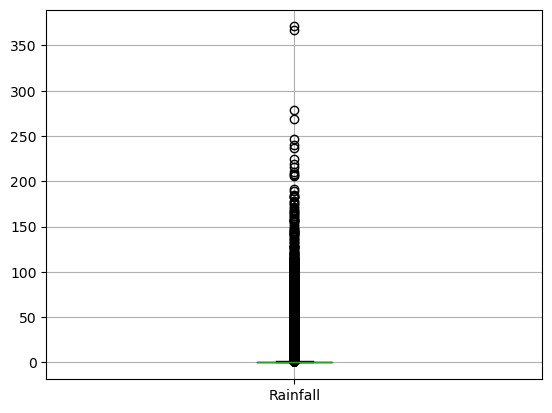

In [45]:
df.boxplot(column='Rainfall')
plt.show()

In [46]:
from scipy.stats import zscore

z = np.abs(zscore(df['Rainfall']))
outliers = df[z > 3]
print(outliers)

        MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
296         9.3     16.8      28.8          4.8       8.4           56.0   
431        19.2     26.1      52.2          4.8       8.4           33.0   
462        18.1     25.5      66.0          4.8       8.4           56.0   
544         9.4     15.0      28.0          4.8       8.4           26.0   
684         4.8     12.8      32.8          4.8       8.4           52.0   
...         ...      ...       ...          ...       ...            ...   
145046     16.3     21.9      39.0          4.8       8.4           35.0   
145095     10.2     15.6      42.0          4.8       8.4           43.0   
145278     22.1     27.4      83.8          4.8       8.4           72.0   
145279     22.1     35.8      63.8          4.8       8.4           43.0   
145393     18.6     28.6      34.6          4.8       8.4           46.0   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  \
296             26

In [47]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


In [48]:
exclude_cols = ['RainTomorrow', 'RainToday']

num_col = [col for col in df.select_dtypes(include=np.number).columns if col not in exclude_cols]

for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

In [49]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


In [50]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [52]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [53]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (101822, 115)
Validation: (21819, 115)
Test: (21819, 115)


In [54]:
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

In [55]:
# import os

# base_path = r'M:\ML_Project\weathercast-ml-system\data\processed'

# os.makedirs(base_path, exist_ok=True)

In [56]:
# train_df.to_csv(base_path + r'\train.csv', index=False)
# val_df.to_csv(base_path + r'\validation.csv', index=False)
# test_df.to_csv(base_path + r'\test.csv', index=False)

In [57]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (101822, 116)
Validation: (21819, 116)
Test: (21819, 116)


In [58]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

In [59]:
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'month_sin', 'month_cos'],
      dtype='object')


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [61]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

In [62]:
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.coef_)   # weights
print(model.intercept_)

[[ 2.03797197e-01 -6.76249191e-02  6.55509143e-02 -1.68963016e-02
  -3.23796911e-01  3.71507624e-01 -6.41137962e-02 -1.02479769e-01
   2.40530984e-01  7.90610706e-01 -2.15880801e-01 -3.30037553e-01
   1.17897350e-01  3.54183487e-01  1.34632654e-01 -1.34521688e-01
   1.79851231e-02 -9.93566311e-04  2.20695300e-02 -2.93787492e-03
  -4.99055838e-02 -1.47077093e-01  9.26324984e-03  1.03447355e-03
  -9.57815454e-03  6.91692760e-03 -1.19607148e-02 -2.07518969e-03
   1.72318360e-02  9.10745311e-03 -2.87263244e-03 -5.08618364e-03
   1.49259757e-02  6.84283583e-03  1.07416380e-03  3.62044389e-03
  -1.39324691e-02 -4.76299748e-03 -3.67782358e-03 -1.69988993e-02
  -1.85419602e-02 -1.13426774e-02 -6.10019148e-03  4.27487153e-04
  -7.02975776e-03  1.31049294e-02 -4.73606556e-03  2.09739775e-03
  -1.64477172e-04 -4.37246584e-03 -2.00302021e-03  1.09726559e-02
   9.86592323e-03  5.32962279e-03  2.15065350e-03  2.40359133e-03
  -1.45673337e-02  2.60221388e-03  9.31665287e-03  4.21608814e-03
  -1.53614

c:\Users\rupak\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Serialization

Model serialization is the process of saving a trained machine learning model and related preprocessing objects into a file so that the model does not need to be trained again every time. The saved model can be loaded later and used directly for prediction.

model.pkl      → trained model
scaler.pkl     → preprocessing scaler
encoder.pkl    → label encoder / one-hot encoder

Method	                          Used For

joblib	      ---->          Scikit-learn models (best choice)
pickle	      ---->          General Python objects
.h5	          ---->          Keras models
.pt / .pth	  ---->          PyTorch models

-- In joblib.dump in machine learning, the "dump" refers to Serializing a Python object (such as a trained ML model) and writing that serialized data to a file on disk. This process is also known as persistence or pickling.